# Project Objective
The goal of this project is to analyze probability patterns from student data
and predict whether a student will pass the final mathematics exam.
The dataset contains study hours, attendance, group discussion participation,
previous test score and final exam result.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [6]:
np.random.seed(42)

n = 200

study_hours = np.random.randint(1,20,n)
attendance = np.random.randint(50,100,n)
group_discussion = np.random.choice(["Yes","No"],n)
previous_test_score = np.random.randint(40,100,n)

final_exam_pass = []

for score in previous_test_score:
    if score > 60:
        final_exam_pass.append("Pass")
    else:
        final_exam_pass.append("Fail")

df = pd.DataFrame({
    "study_hours":study_hours,
    "attendance":attendance,
    "group_discussion":group_discussion,
    "previous_test_score":previous_test_score,
    "final_exam_pass":final_exam_pass
})

df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,7,60,No,44,Fail
1,15,77,Yes,74,Pass
2,11,74,Yes,51,Fail
3,8,99,No,64,Pass
4,7,72,No,91,Pass


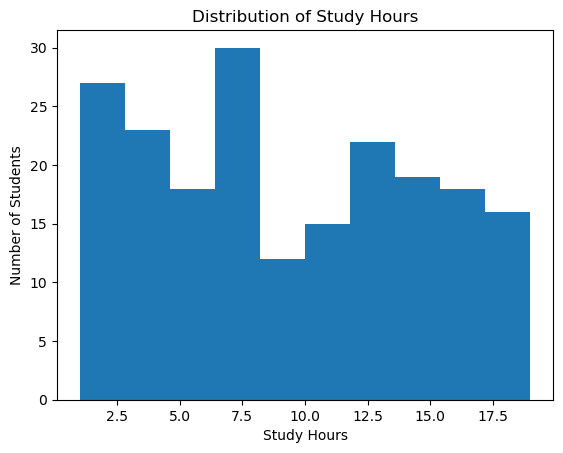

In [19]:
plt.figure()

plt.hist(df['study_hours'], bins=10)

plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")

plt.show()

This histogram shows the distribution of study hours among students.
Most students study between 5 and 15 hours per week.
Students who study more hours are more likely to pass the exam.

# 1 Understanding the Basics

# What is Probability
Probability is the measure of how likely an event is to occur.
It ranges from 0 to 1.

0 means impossible event  
1 means certain event

# Key Probability Terminology

Event : A specific outcome  
Sample Space : All possible outcomes  
Probability : Likelihood of an event occurring  
Random Variable : Numeric representation of outcomes

# Examples of Probability Events from Dataset

1 Student studies more than 10 hours per week  
2 Student attendance is greater than 80 percent  
3 Student passes the final exam

In [7]:
pass_count = (df['final_exam_pass']=="Pass").sum()

empirical_probability = pass_count / len(df)

empirical_probability

np.float64(0.65)

# 2 Types of Events

# Empirical Probability
Empirical probability is calculated using real data observations.

# Theoretical Probability
Theoretical probability is calculated using mathematical formulas
based on expected outcomes.

In [8]:
theoretical_probability = 1/2
theoretical_probability

0.5

# 3 Random Variable and Probability Distribution

Let X be the number of students passing the exam out of 3 randomly selected students.

Possible values of X

0 students pass  
1 student passes  
2 students pass  
3 students pass

In [9]:
x = np.array([0,1,2,3])
p = np.array([0.05,0.25,0.45,0.25])

distribution = pd.DataFrame({
    "X (Students Passing)":x,
    "Probability":p
})

distribution

,X (Students Passing),Probability
0,0,0.05
1,1,0.25
2,2,0.45
3,3,0.25


In [10]:
mean = np.sum(x*p)

variance = np.sum((x-mean)**2 * p)

print("Mean:",mean)
print("Variance:",variance)

Mean: 1.9
Variance: 0.69


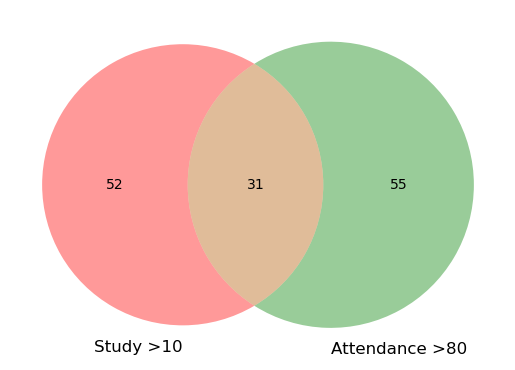

In [11]:
A = df[df.study_hours > 10]
B = df[df.attendance > 80]

A_count = len(A)
B_count = len(B)

both = len(df[(df.study_hours > 10) & (df.attendance > 80)])

venn2(subsets = (A_count-both,B_count-both,both),
      set_labels=('Study >10','Attendance >80'))

plt.show()

In [12]:
table = pd.crosstab(df['group_discussion'],df['final_exam_pass'])

table

final_exam_pass,Fail,Pass
group_discussion,,
No,36,64
Yes,34,66


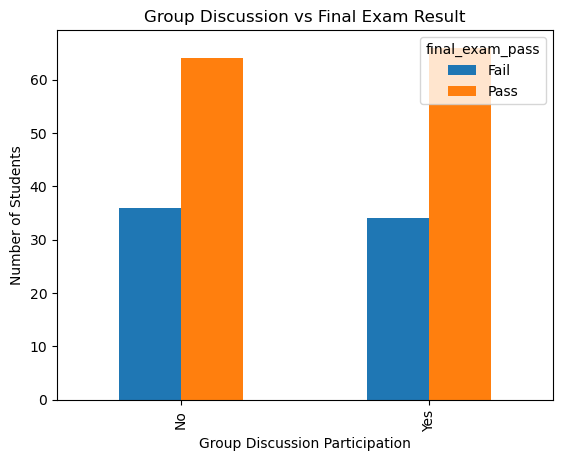

In [21]:
table.plot(kind='bar')

plt.title("Group Discussion vs Final Exam Result")
plt.xlabel("Group Discussion Participation")
plt.ylabel("Number of Students")

plt.show()

The chart shows the relationship between group discussion participation
and exam results. Students who participate in discussions tend to
have higher pass rates compared to those who do not.

In [13]:
joint_probability = len(df[(df.group_discussion=="Yes") & (df.final_exam_pass=="Pass")]) / len(df)

joint_probability

0.33

In [14]:
marginal_probability = pass_count / len(df)

marginal_probability

np.float64(0.65)

In [15]:
conditional_probability = table.loc["Yes","Pass"] / table.loc["Yes"].sum()

conditional_probability

np.float64(0.66)

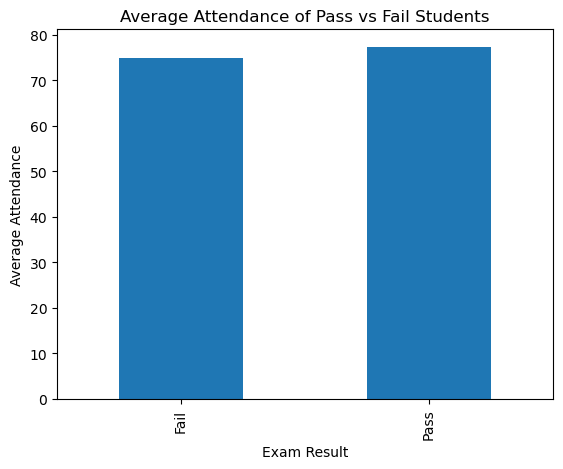

In [20]:
attendance_pass = df.groupby('final_exam_pass')['attendance'].mean()

plt.figure()

attendance_pass.plot(kind='bar')

plt.title("Average Attendance of Pass vs Fail Students")
plt.xlabel("Exam Result")
plt.ylabel("Average Attendance")

plt.show()

This chart shows the average attendance of students who passed
and failed the exam. Students who passed generally have higher
attendance compared to those who failed.

## 6 Understanding Relationships

Conditional probability shows how the probability of passing
changes when students participate in group discussions.

If students who participate in discussions have higher probability
of passing the exam, then the events are dependent.

This means participation in group discussions increases
the chance of passing the exam.

## 7 Bayes Theorem Application

Given:

70 percent of students who pass had high attendance  
40 percent of students who fail also had high attendance  
60 percent of all students had high attendance

Using Bayes theorem we can calculate the probability
that a student passed the exam given that they had high attendance.

In [17]:
P_A = 0.6
P_B_given_A = 0.7
P_B = 0.6

bayes = (P_B_given_A * P_A) / P_B

bayes

0.7

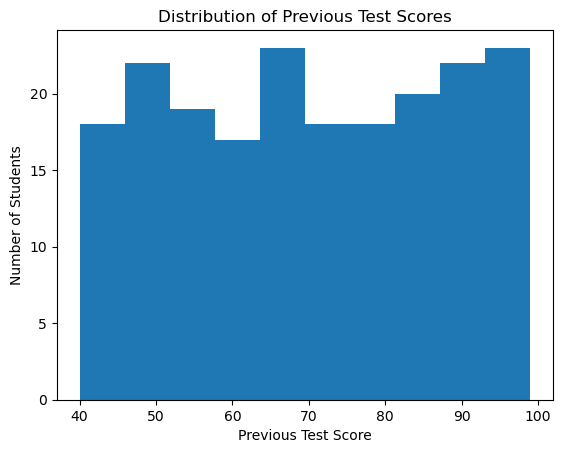

In [22]:
plt.figure()

plt.hist(df['previous_test_score'], bins=10)

plt.title("Distribution of Previous Test Scores")
plt.xlabel("Previous Test Score")
plt.ylabel("Number of Students")

plt.show()

This histogram shows the distribution of previous test scores.
Students with higher previous test scores tend to have a higher
probability of passing the final exam.

## Final Summary

The analysis shows that students who study more hours,
attend classes regularly and participate in group discussions
have a higher probability of passing the exam.

Attendance above 80 percent and higher previous test scores
are strong indicators of final exam success.

Therefore study habits, attendance and participation
significantly affect the probability of passing the exam.